# Enron Email Network – Task 4: Covert Cluster & Anomaly Detection

**Pipeline overview**

| Phase | Purpose |
|---|---|
| 1. Setup & Data | Load edges, build K-core subgraph |
| 2. Community Detection | Louvain & Leiden partitions |
| 3. Community-Level Analysis | Structure metrics → covert-candidate flagging |
| 4. Node-Level Feature Engineering | Betweenness, constraint, span, reciprocity → Broker/Handler classification |
| 5. Statistical Anomaly Detection | Isolation Forest + LOF → consensus anomalies |
| 6. Validation & Synthesis | Modularity null test, composite suspicion score, ground-truth check |

---
## Phase 1 — Setup & Data

In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import community as community_louvain
import leidenalg as la
import igraph as ig
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy import stats as sp_stats
from matplotlib.lines import Line2D

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

In [5]:
# ── Load data ─────────────────────────────────────────────────────────────────
edges_df   = pd.read_csv('enron_weighted_edges.csv')
full_df    = pd.read_csv('enron_full_edgelist.csv')
mapping_df = pd.read_csv('id_mapping.csv')
id_to_email = dict(zip(mapping_df['ID'], mapping_df['Email_Address']))

# Remove self-loops
edges_df = edges_df[edges_df['Source'] != edges_df['Target']].copy()

# Full directed weighted graph
G_full = nx.from_pandas_edgelist(
    edges_df, source='Source', target='Target',
    edge_attr='Weight', create_using=nx.DiGraph()
)

# ── K-core subgraph ────────────────────────────────────────────────────────────
CHOSEN_K = 5
G_und_full  = G_full.to_undirected()
kcore_nodes = nx.k_core(G_und_full, k=CHOSEN_K).nodes()
G_dir   = G_full.subgraph(kcore_nodes).copy()
G_undir = G_dir.to_undirected()

# Inverse-weight distance for shortest-path centrality
for u, v, d in G_dir.edges(data=True):
    d['distance'] = 1.0 / d['Weight']

print(f'K-core (k={CHOSEN_K}) subgraph : {G_dir.number_of_nodes():,} nodes  |  {G_dir.number_of_edges():,} edges')
print(f'Weakly connected components   : {nx.number_weakly_connected_components(G_dir)}')

K-core (k=5) subgraph : 9,066 nodes  |  160,005 edges
Weakly connected components   : 1


---
## Phase 2 — Community Detection (Louvain & Leiden)

In [7]:
# ── Louvain ───────────────────────────────────────────────────────────────────
partition_louvain = community_louvain.best_partition(G_undir, weight='Weight', random_state=42)
n_comm_louvain = len(set(partition_louvain.values()))
mod_louvain    = community_louvain.modularity(partition_louvain, G_undir, weight='Weight')
print(f'Louvain  →  {n_comm_louvain} communities  |  modularity = {mod_louvain:.4f}')

# ── Leiden ────────────────────────────────────────────────────────────────────
ig_graph = ig.Graph.TupleList(G_undir.edges(data='Weight'), weights=True)
weights  = [float(w) for w in ig_graph.es['weight']]
part_leiden = la.find_partition(ig_graph, la.ModularityVertexPartition, weights=weights)
partition_leiden = {
    ig_graph.vs[i]['name']: comm_id
    for i, comm_id in enumerate(part_leiden.membership)
}
n_comm_leiden = len(set(partition_leiden.values()))
print(f'Leiden   →  {n_comm_leiden} communities  |  modularity = {part_leiden.modularity:.4f}')

Louvain  →  19 communities  |  modularity = 0.6394
Leiden   →  20 communities  |  modularity = 0.5344


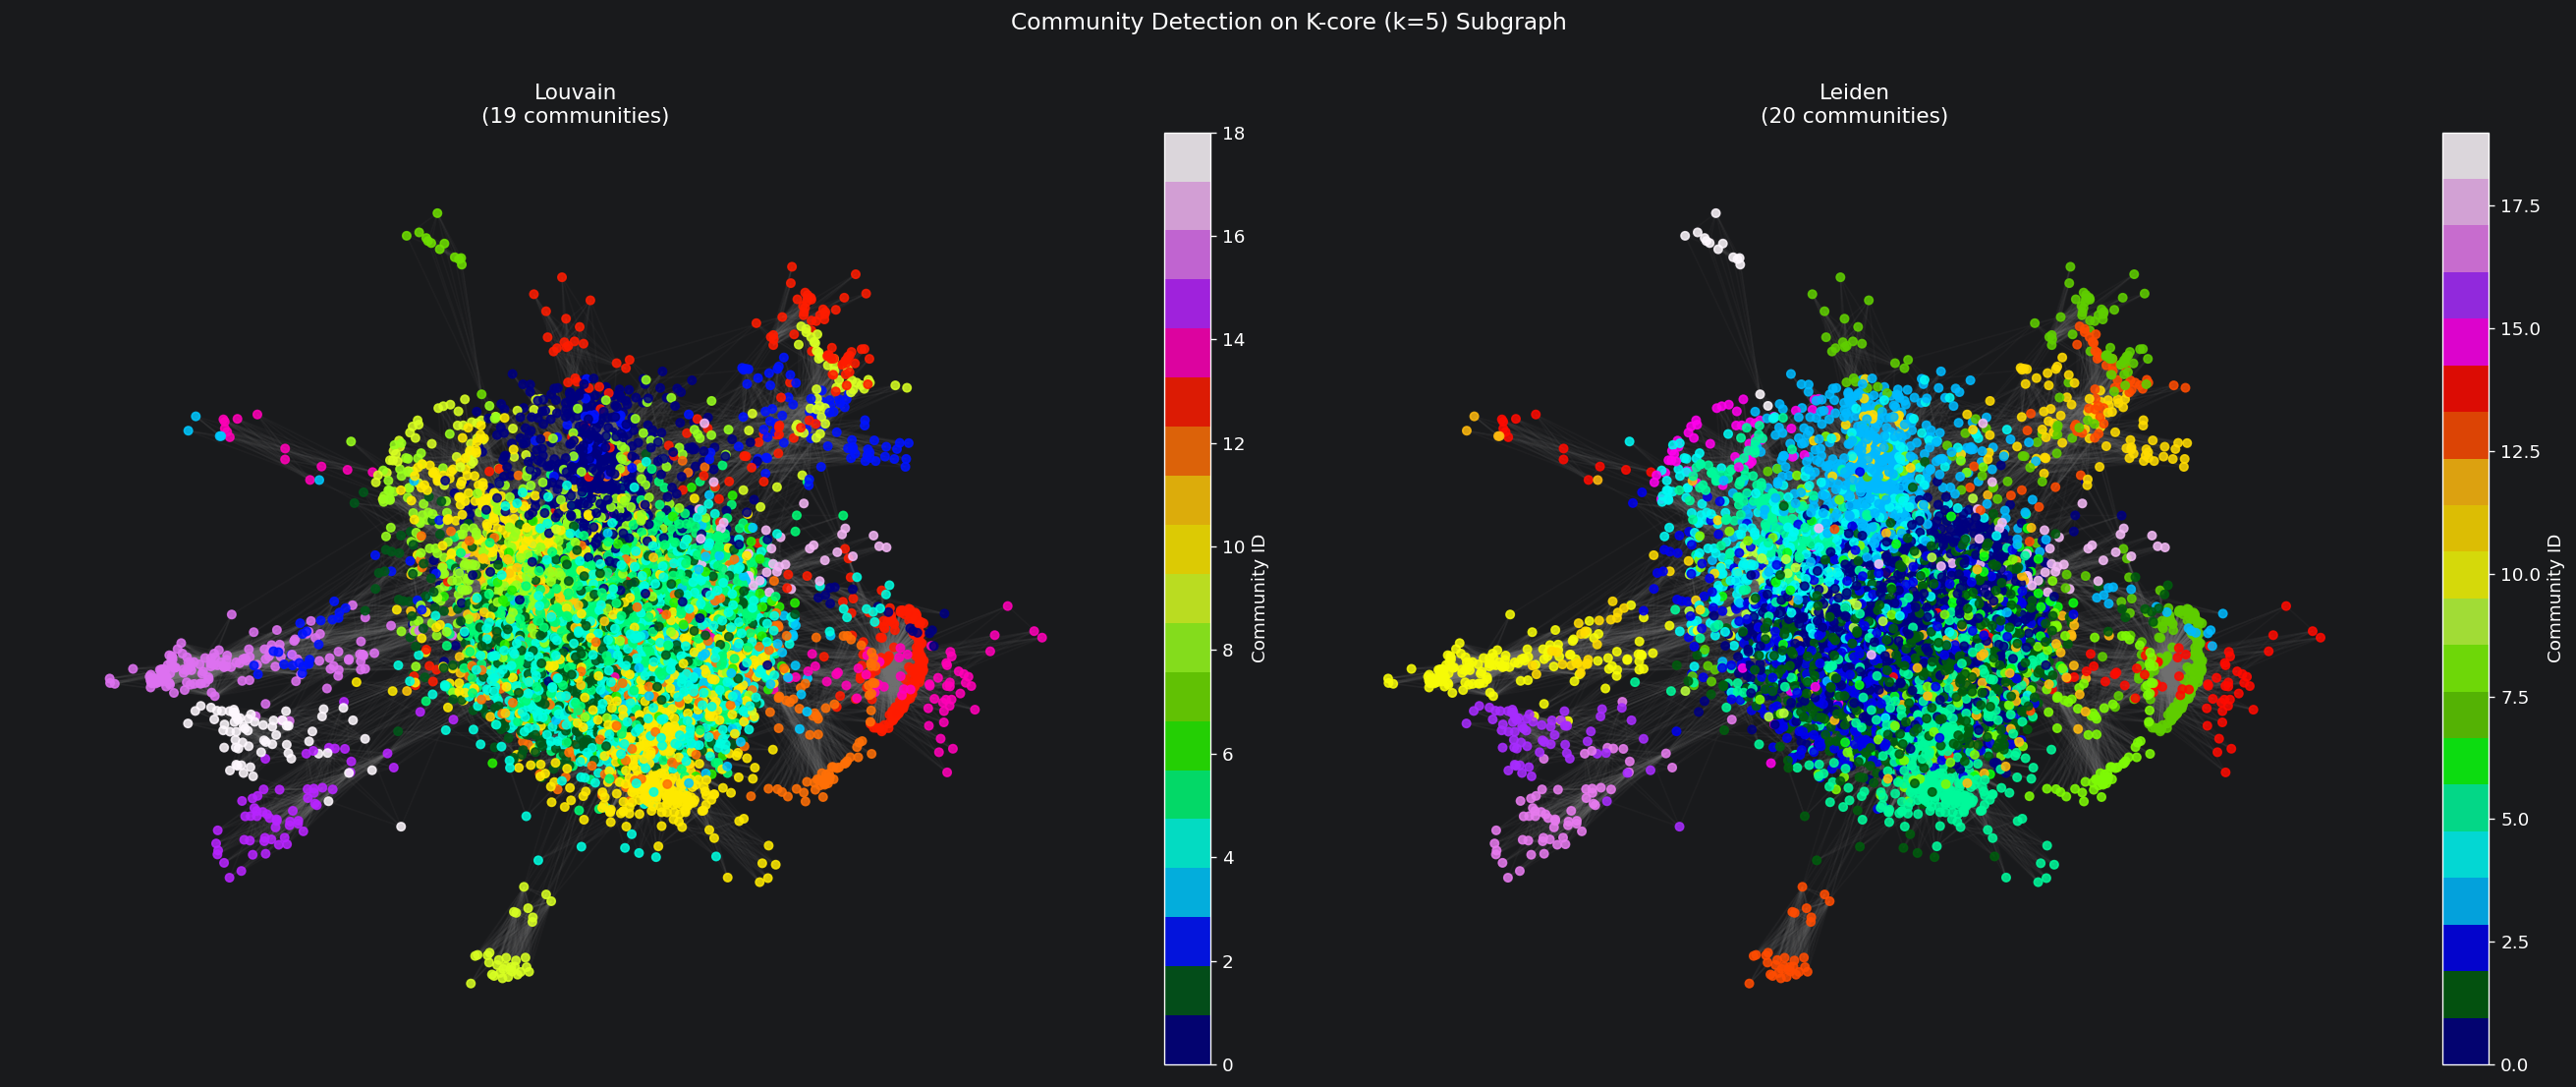

In [8]:
# ── Visualise side-by-side ────────────────────────────────────────────────────
pos = nx.spring_layout(G_dir, k=0.15, seed=42)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

def draw_partition(ax, partition, title, n_comms):
    cmap = plt.colormaps['gist_ncar'].resampled(n_comms)
    node_colors = [partition.get(node, 0) for node in G_dir.nodes()]
    nx.draw_networkx_edges(G_dir, pos, ax=ax, alpha=0.06, edge_color='gray', arrows=False)
    sc = nx.draw_networkx_nodes(G_dir, pos, ax=ax, node_size=25,
                                node_color=node_colors, cmap=cmap, alpha=0.85)
    ax.set_title(f'{title}\n({n_comms} communities)', fontsize=13)
    ax.axis('off')
    return sc

sc1 = draw_partition(axes[0], partition_louvain, 'Louvain', n_comm_louvain)
sc2 = draw_partition(axes[1], partition_leiden,  'Leiden',  n_comm_leiden)
fig.colorbar(sc1, ax=axes[0], label='Community ID', fraction=0.04, pad=0.02)
fig.colorbar(sc2, ax=axes[1], label='Community ID', fraction=0.04, pad=0.02)
plt.suptitle(f'Community Detection on K-core (k={CHOSEN_K}) Subgraph', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## Phase 3 — Community-Level Anomaly Detection

For each community we compute:
- **Internal density** — fraction of possible internal edges that exist
- **Average internal degree** — mean connections within the community
- **Conductance** — ratio of external to total edges (lower = more insular)

Communities with **high density + low conductance** are flagged as covert candidates.

In [9]:
def community_metrics(G_directed, partition, label=''):
    """Compute structural metrics for each community in the partition."""
    rows = []
    for comm_id in sorted(set(partition.values())):
        nodes = [n for n, c in partition.items() if c == comm_id]
        if len(nodes) < 2:
            continue
        sub = G_directed.subgraph(nodes)
        n, m = len(nodes), sub.number_of_edges()
        internal_density    = m / (n * (n - 1)) if n > 1 else 0
        avg_internal_degree = np.mean([d for _, d in sub.degree()])
        nodes_set = set(nodes)
        external_edges = sum(
            1 for nd in nodes
            for nb in G_directed.successors(nd) if nb not in nodes_set
        ) + sum(
            1 for nd in nodes
            for nb in G_directed.predecessors(nd) if nb not in nodes_set
        )
        total_deg   = sum(dict(G_directed.degree(nodes)).values())
        conductance = external_edges / total_deg if total_deg > 0 else 0
        rows.append({
            'community_id': comm_id, 'size': n,
            'internal_edges': m, 'internal_density': internal_density,
            'avg_internal_degree': avg_internal_degree,
            'external_edges': external_edges,
            'conductance': conductance, 'nodes': nodes,
        })
    df = pd.DataFrame(rows)
    if label:
        print(f'\n--- {label} — Top 10 Communities by Size ---')
        cols = ['community_id','size','internal_density','avg_internal_degree','external_edges','conductance']
        print(df.sort_values('size', ascending=False).head(10)[cols].to_string(index=False))
    return df

df_louvain = community_metrics(G_dir, partition_louvain, 'Louvain')
df_leiden  = community_metrics(G_dir, partition_leiden,  'Leiden')


--- Louvain — Top 10 Communities by Size ---
 community_id  size  internal_density  avg_internal_degree  external_edges  conductance
            5  1710          0.005906            20.187135           27442     0.442884
            4  1605          0.006628            21.263551           22836     0.400885
            1  1111          0.014011            31.103510           20650     0.374054
            0   857          0.016223            27.773629            5125     0.177170
            8   847          0.017045            28.840614           13370     0.353722
           10   743          0.018783            27.873486            1967     0.086740
            6   411          0.028265            23.177616           10049     0.513359
           12   341          0.014732            10.017595            2275     0.399754
           13   340          0.019183            13.005882             178     0.038696
           11   248          0.052191            25.782258            4599

In [10]:
def find_covert_candidates(df_metrics, label=''):
    """Flag communities with high internal density AND low conductance."""
    high_density_thresh    = df_metrics['internal_density'].quantile(0.75)
    low_conductance_thresh = df_metrics['conductance'].quantile(0.25)
    anomalies = df_metrics[
        (df_metrics['internal_density'] >= high_density_thresh) &
        (df_metrics['conductance']      <= low_conductance_thresh)
    ]
    print(f'\n--- {label} — Covert-candidate Communities ---')
    print(f'  Density  >= {high_density_thresh:.4f}  (75th pct)')
    print(f'  Conduct. <= {low_conductance_thresh:.4f}  (25th pct)')
    if anomalies.empty:
        print('  None found.')
    else:
        cols = ['community_id','size','internal_density','conductance','external_edges']
        print(anomalies[cols].to_string(index=False))
    return anomalies

covert_louvain = find_covert_candidates(df_louvain, 'Louvain')
covert_leiden  = find_covert_candidates(df_leiden,  'Leiden')


--- Louvain — Covert-candidate Communities ---
  Density  >= 0.0820  (75th pct)
  Conduct. <= 0.0922  (25th pct)
 community_id  size  internal_density  conductance  external_edges
           15    60          0.129944     0.054471              53
           16   154          0.099058     0.049094             241
           18    66          0.085315     0.043137              33

--- Leiden — Covert-candidate Communities ---
  Density  >= 0.0817  (75th pct)
  Conduct. <= 0.0848  (25th pct)
 community_id  size  internal_density  conductance  external_edges
           10   154          0.099058     0.049094             241
           16    66          0.085315     0.043137              33
           17    59          0.133548     0.055785              54


In [11]:
def inspect_covert_community(covert_df, partition, partition_name):
    """Show top-degree members within each covert-candidate community."""
    print(f'\n== {partition_name} — Covert Community Member Inspection ==')
    for _, row in covert_df.iterrows():
        cid   = int(row['community_id'])
        nodes = row['nodes']
        sub   = G_dir.subgraph(nodes)
        top5  = sorted(sub.degree(), key=lambda x: x[1], reverse=True)[:5]
        print(f'\n  Community {cid}  (n={int(row["size"])}, '
              f'density={row["internal_density"]:.4f}, '
              f'conductance={row["conductance"]:.4f})')
        print('  Top-5 nodes by internal degree:')
        for node, deg in top5:
            email = id_to_email.get(node, str(node))
            print(f'    {str(email).ljust(45)}  internal_degree={deg}')

inspect_covert_community(covert_louvain, partition_louvain, 'Louvain')
inspect_covert_community(covert_leiden,  partition_leiden,  'Leiden')


== Louvain — Covert Community Member Inspection ==

  Community 15  (n=60, density=0.1299, conductance=0.0545)
  Top-5 nodes by internal degree:
    hollis.kimbrough@enron.com                     internal_degree=59
    mark.walker@enron.com                          internal_degree=50
    mark.fisher@enron.com                          internal_degree=47
    jeff.maurer@enron.com                          internal_degree=44
    jeff.duff@enron.com                            internal_degree=42

  Community 16  (n=154, density=0.0991, conductance=0.0491)
  Top-5 nodes by internal degree:
    jeffn@subutil.com                              internal_degree=135
    erick_johnson@pngc.com                         internal_degree=134
    lwolv@worldaccessnet.com                       internal_degree=127
    jpw@duncanallen.com                            internal_degree=126
    tdeboer@painehamblen.com                       internal_degree=126

  Community 18  (n=66, density=0.0853, conductance=0.

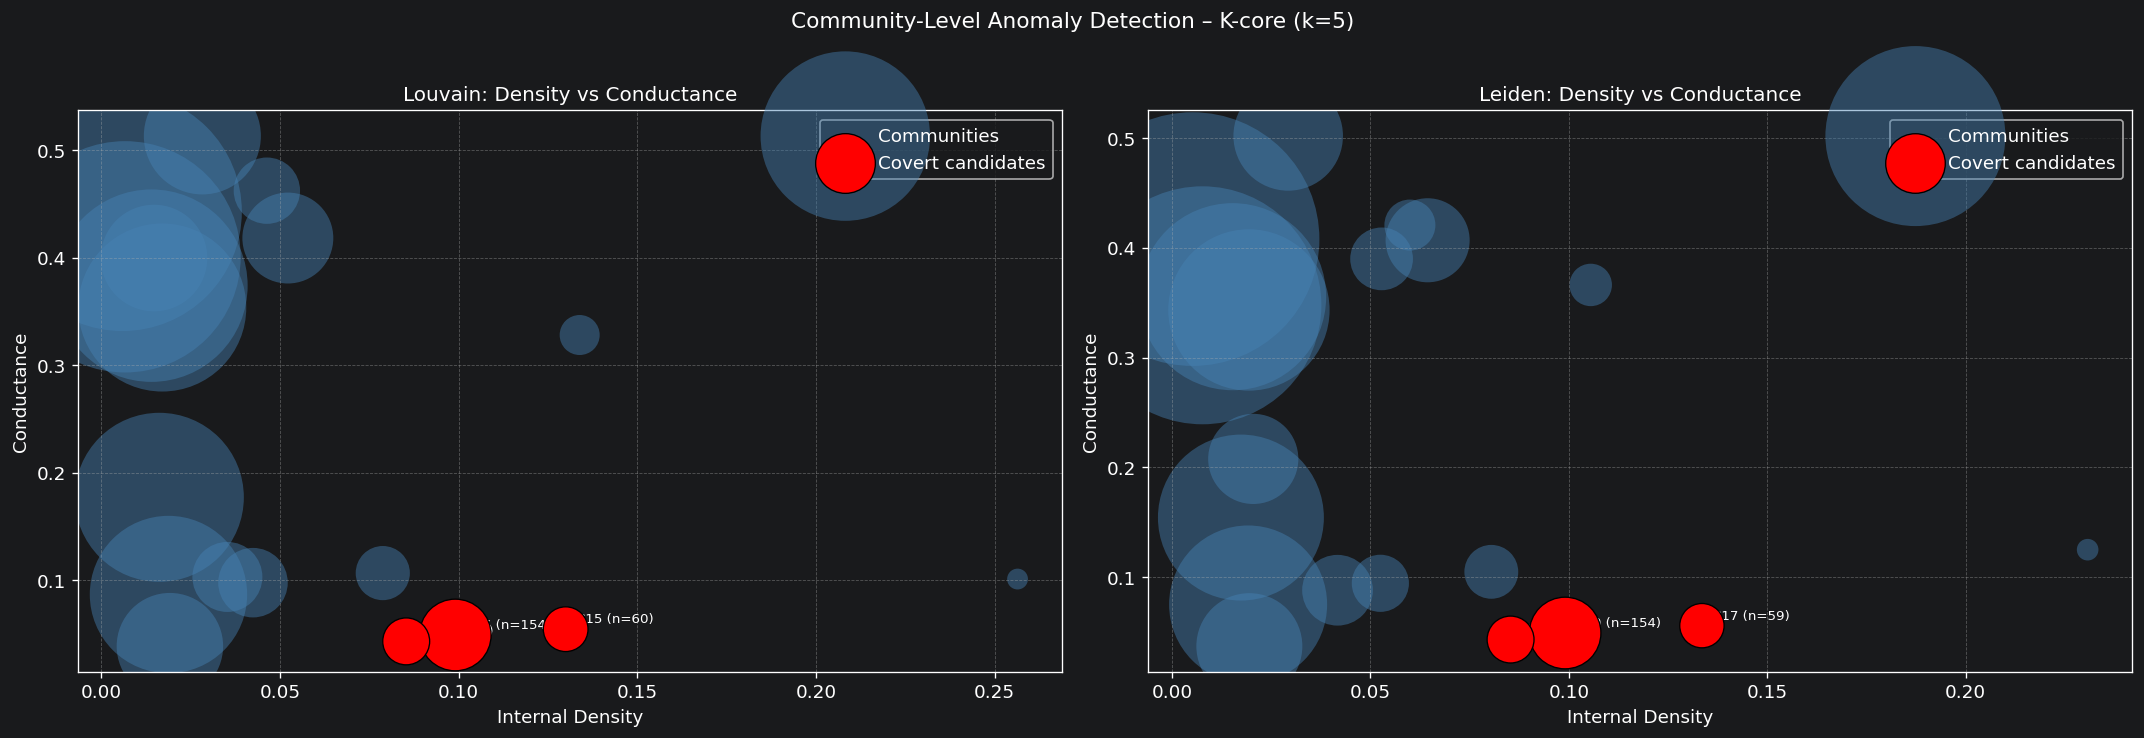

Louvain flagged: 3 / 19 communities
Leiden  flagged: 3  / 20 communities
Nodes flagged by both: 279


In [31]:
# ── Density vs Conductance landscape ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, df_m, covert, title in [
    (axes[0], df_louvain, covert_louvain, 'Louvain'),
    (axes[1], df_leiden,  covert_leiden,  'Leiden'),
]:
    ax.scatter(df_m['internal_density'], df_m['conductance'],
               s=df_m['size'] * 12, alpha=0.45, color='steelblue',
               label='Communities', edgecolors='none')
    if not covert.empty:
        ax.scatter(covert['internal_density'], covert['conductance'],
                   s=covert['size'] * 12, color='red', zorder=5,
                   label='Covert candidates', edgecolors='black', linewidths=0.8)
        for _, row in covert.iterrows():
            ax.annotate(f"C{int(row['community_id'])} (n={int(row['size'])})",
                        (row['internal_density'], row['conductance']),
                        textcoords='offset points', xytext=(6, 4), fontsize=8)
    ax.set_title(f'{title}: Density vs Conductance', fontsize=12)
    ax.set_xlabel('Internal Density')
    ax.set_ylabel('Conductance')
    ax.legend(); ax.grid(True, linestyle='--', alpha=0.4)
plt.suptitle(f'Community-Level Anomaly Detection – K-core (k={CHOSEN_K})', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

# ── Cross-method agreement ────────────────────────────────────────────────────
louvain_nodes = set().union(*covert_louvain['nodes'].tolist()) if not covert_louvain.empty else set()
leiden_nodes  = set().union(*covert_leiden['nodes'].tolist())  if not covert_leiden.empty  else set()
overlap_comm  = louvain_nodes & leiden_nodes
print(f'Louvain flagged: {len(covert_louvain)} / {len(df_louvain)} communities')
print(f'Leiden  flagged: {len(covert_leiden)}  / {len(df_leiden)} communities')
print(f'Nodes flagged by both: {len(overlap_comm)}')

In [13]:
# ── Louvain vs Leiden head-to-head ────────────────────────────────────────────
print('{:<45} {:>12} {:>12}'.format('Metric', 'Louvain', 'Leiden'))
print('-' * 71)
rows_cmp = [
    ('Number of communities',       n_comm_louvain,                      n_comm_leiden),
    ('Modularity',                   round(mod_louvain, 4),               round(part_leiden.modularity, 4)),
    ('Largest community (nodes)',    df_louvain['size'].max(),            df_leiden['size'].max()),
    ('Smallest community (nodes)',   df_louvain['size'].min(),            df_leiden['size'].min()),
    ('Mean community size',          round(df_louvain['size'].mean(), 1), round(df_leiden['size'].mean(), 1)),
    ('Covert-candidate communities', len(covert_louvain),                 len(covert_leiden)),
    ('Mean internal density',        round(df_louvain['internal_density'].mean(), 4),
                                     round(df_leiden['internal_density'].mean(),  4)),
    ('Mean conductance',             round(df_louvain['conductance'].mean(), 4),
                                     round(df_leiden['conductance'].mean(),  4)),
]
for lbl, v1, v2 in rows_cmp:
    print('{:<45} {:>12} {:>12}'.format(lbl, str(v1), str(v2)))

Metric                                             Louvain       Leiden
-----------------------------------------------------------------------
Number of communities                                   19           20
Modularity                                          0.6394       0.5344
Largest community (nodes)                             1710         1930
Smallest community (nodes)                              13           14
Mean community size                                  477.2        453.3
Covert-candidate communities                             3            3
Mean internal density                               0.0579        0.058
Mean conductance                                    0.2396       0.2287


---
## Phase 4 — Node-Level Feature Engineering

We build a per-node feature table (`bridge_df`) combining:

| Feature | What it captures |
|---|---|
| Betweenness centrality | Path control — nodes that sit on many shortest paths |
| Handler score (betweenness / degree) | Disproportionate path control relative to connectivity |
| Burt's constraint | Ego-network redundancy — low = spans structural holes |
| Community span | Number of distinct communities a node's neighbours belong to |
| Reciprocity | Fraction of mutual (bidirectional) ties — low = asymmetric communication |
| Clustering coefficient | Local density around a node |

In [14]:
# ── Betweenness centrality ────────────────────────────────────────────────────
print('Computing betweenness centrality...')
betweenness = nx.betweenness_centrality(G_dir, weight='distance')
print('Done.')

bridge_df = pd.DataFrame({
    'Node_ID':    list(betweenness.keys()),
    'Betweenness': list(betweenness.values()),
    'In_Degree':  [G_dir.in_degree(n)  for n in betweenness],
    'Out_Degree': [G_dir.out_degree(n) for n in betweenness],
})
bridge_df['Total_Degree']      = bridge_df['In_Degree'] + bridge_df['Out_Degree']
bridge_df['Email']             = bridge_df['Node_ID'].map(id_to_email)
bridge_df['Community_Leiden']  = bridge_df['Node_ID'].map(partition_leiden)
bridge_df['Community_Louvain'] = bridge_df['Node_ID'].map(partition_louvain)
bridge_df['handler_score']     = bridge_df['Betweenness'] / (bridge_df['Total_Degree'] + 1)

print('\n--- Top 20 Nodes by Betweenness Centrality ---')
top20_bt = bridge_df.sort_values('Betweenness', ascending=False).head(20).reset_index(drop=True)
top20_bt.index += 1
print(top20_bt[['Email','Node_ID','Betweenness','In_Degree','Out_Degree',
                'Total_Degree','Community_Leiden']].to_string())

Computing betweenness centrality...
Done.

--- Top 20 Nodes by Betweenness Centrality ---
                          Email  Node_ID  Betweenness  In_Degree  Out_Degree  Total_Degree  Community_Leiden
1       jeff.dasovich@enron.com      585     0.255010        478         783          1261                 4
2          tana.jones@enron.com     4377     0.112113        495         591          1086                 2
3         susan.scott@enron.com     5556     0.091321        127         555           682                 5
4     sara.shackleton@enron.com     4404     0.081260        473         479           952                 2
5       james.steffes@enron.com      802     0.070022        172         207           379                 4
6         mark.taylor@enron.com     3207     0.063355        436         446           882                 2
7     jeffery.fawcett@enron.com    18646     0.062216         32          46            78                 3
8      louise.kitchen@enron.com     10

In [15]:
# ── Burt's structural constraint ──────────────────────────────────────────────
print('Computing Burt structural constraint...')
constraint = nx.constraint(G_undir, weight='Weight')
bridge_df['Constraint'] = bridge_df['Node_ID'].map(constraint)
print('Done.')
print('\nConstraint descriptive stats:')
print(bridge_df['Constraint'].describe().round(4))

Computing Burt structural constraint...
Done.

Constraint descriptive stats:
count    9066.0000
mean        0.1897
std         0.1319
min         0.0025
25%         0.0944
50%         0.1626
75%         0.2454
max         0.9836
Name: Constraint, dtype: float64


In [16]:
# ── Community span ────────────────────────────────────────────────────────────
def community_span(node, partition, G):
    """Count distinct communities among a node's direct neighbours."""
    return len(set(
        partition.get(n) for n in G.neighbors(node)
        if partition.get(n) is not None
    ))

print('Computing community span...')
bridge_df['Comm_Span_Leiden']  = bridge_df['Node_ID'].apply(
    lambda n: community_span(n, partition_leiden, G_undir))
bridge_df['Comm_Span_Louvain'] = bridge_df['Node_ID'].apply(
    lambda n: community_span(n, partition_louvain, G_undir))
print('Done.')

print('\nTop 10 nodes by community span (Leiden):')
top_span = bridge_df.sort_values('Comm_Span_Leiden', ascending=False).head(10)
print(top_span[['Email','Betweenness','Total_Degree','Comm_Span_Leiden','Constraint']].to_string(index=False))

Computing community span...
Done.

Top 10 nodes by community span (Leiden):
                       Email  Betweenness  Total_Degree  Comm_Span_Leiden  Constraint
       kenneth.lay@enron.com 1.866034e-02          1310                14    0.006167
      gerald.nemec@enron.com 5.466564e-02           747                14    0.024513
jacqueline.coleman@enron.com 2.149599e-03           430                12    0.009965
     billy.lemmons@enron.com 1.785788e-03           712                12    0.006086
    alicia.jenkins@enron.com 2.434122e-08           315                12    0.010468
     jeff.skilling@enron.com 6.105021e-03           476                12    0.014133
       kay.chapman@enron.com 2.085851e-02           494                12    0.014970
         mary.hain@enron.com 1.651122e-02           500                12    0.030595
      paul.kaufman@enron.com 1.143173e-03           421                12    0.063247
       mark.taylor@enron.com 6.335549e-02           882         

In [17]:
# ── Directed reciprocity ──────────────────────────────────────────────────────
global_rec = nx.overall_reciprocity(G_dir)
print(f'Global network reciprocity: {global_rec:.4f}')
print('(1.0 = all edges mutual; 0.0 = fully asymmetric)')

def node_reciprocity(node, G):
    out_n = set(G.successors(node))
    in_n  = set(G.predecessors(node))
    union = out_n | in_n
    if not union:
        return np.nan
    return len(out_n & in_n) / len(union)

print('Computing per-node reciprocity...')
bridge_df['Reciprocity'] = bridge_df['Node_ID'].apply(lambda n: node_reciprocity(n, G_dir))
print('Done.')
print('\nReciprocity descriptive stats:')
print(bridge_df['Reciprocity'].describe().round(4))

Global network reciprocity: 0.2007
(1.0 = all edges mutual; 0.0 = fully asymmetric)
Computing per-node reciprocity...
Done.

Reciprocity descriptive stats:
count    9066.0000
mean        0.0616
std         0.1005
min         0.0000
25%         0.0000
50%         0.0000
75%         0.1000
max         0.8182
Name: Reciprocity, dtype: float64


In [18]:
# ── Clustering coefficient ────────────────────────────────────────────────────
clustering = nx.clustering(G_undir)
bridge_df['Clustering'] = bridge_df['Node_ID'].map(clustering)

In [47]:
# ── Broker vs Handler classification ──────────────────────────────────────────
# Handler candidates: high betweenness (≥95th pct) but NOT high degree (<75th pct)
# Structural brokers: high betweenness AND high degree
bt_thresh  = bridge_df['Betweenness'].quantile(0.95)
deg_thresh = bridge_df['Total_Degree'].quantile(0.75)

def classify_node(row):
    hi_bt  = row['Betweenness']  >= bt_thresh
    hi_deg = row['Total_Degree'] >= deg_thresh
    if hi_bt and not hi_deg:
        return 'Handler candidate'
    elif hi_bt and hi_deg:
        return 'Structural broker (hub)'
    else:
        return 'Background'

bridge_df['Broker_Type'] = bridge_df.apply(classify_node, axis=1)

# Summary
summary = bridge_df[bridge_df['Broker_Type'] != 'Background'].groupby('Broker_Type').agg(
    count           = ('Node_ID',          'count'),
    mean_BT         = ('Betweenness',      'mean'),
    mean_degree     = ('Total_Degree',     'mean'),
    mean_constraint = ('Constraint',       'mean'),
    mean_span       = ('Comm_Span_Leiden', 'mean')
).round(4)
print(summary)

                         count  mean_BT  mean_degree  mean_constraint  \
Broker_Type                                                             
Handler candidate           24   0.0020      19.3333           0.1931   
Structural broker (hub)    430   0.0065     221.6256           0.0654   

                         mean_span  
Broker_Type                         
Handler candidate           2.7500  
Structural broker (hub)     6.5791  


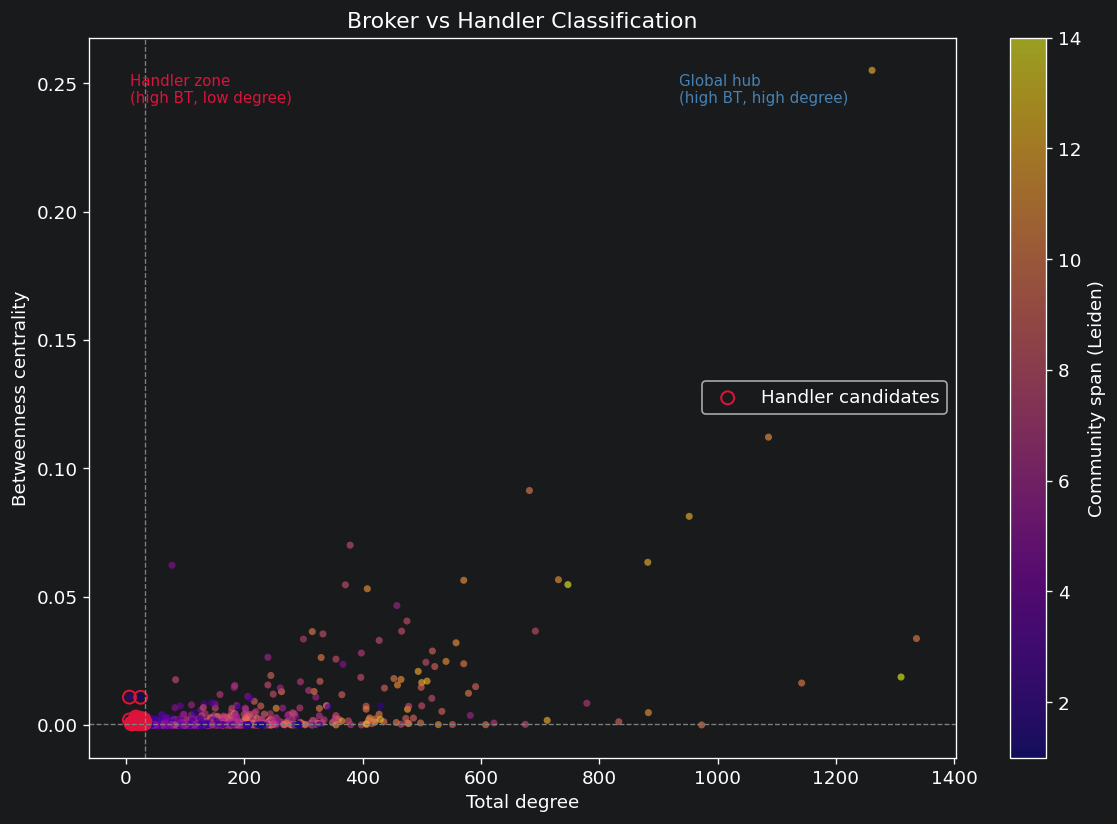

In [20]:
# ── Broker vs Handler scatter ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

sc = ax.scatter(bridge_df['Total_Degree'], bridge_df['Betweenness'],
                c=bridge_df['Comm_Span_Leiden'], cmap='plasma', s=18, alpha=0.6, linewidths=0)
plt.colorbar(sc, ax=ax, label='Community span (Leiden)')

ax.axhline(bt_thresh,  color='gray', linestyle='--', linewidth=0.8)
ax.axvline(deg_thresh, color='gray', linestyle='--', linewidth=0.8)

ax.text(bridge_df['Total_Degree'].min()+2, bridge_df['Betweenness'].max()*0.95,
        'Handler zone\n(high BT, low degree)', fontsize=9, color='crimson')
ax.text(bridge_df['Total_Degree'].max()*0.7, bridge_df['Betweenness'].max()*0.95,
        'Global hub\n(high BT, high degree)', fontsize=9, color='steelblue')

handlers = bridge_df[bridge_df['Broker_Type'] == 'Handler candidate']
ax.scatter(handlers['Total_Degree'], handlers['Betweenness'],
           s=60, facecolors='none', edgecolors='crimson', linewidths=1.2, label='Handler candidates')

ax.set_xlabel('Total degree'); ax.set_ylabel('Betweenness centrality')
ax.set_title('Broker vs Handler Classification'); ax.legend()
plt.tight_layout(); plt.show()

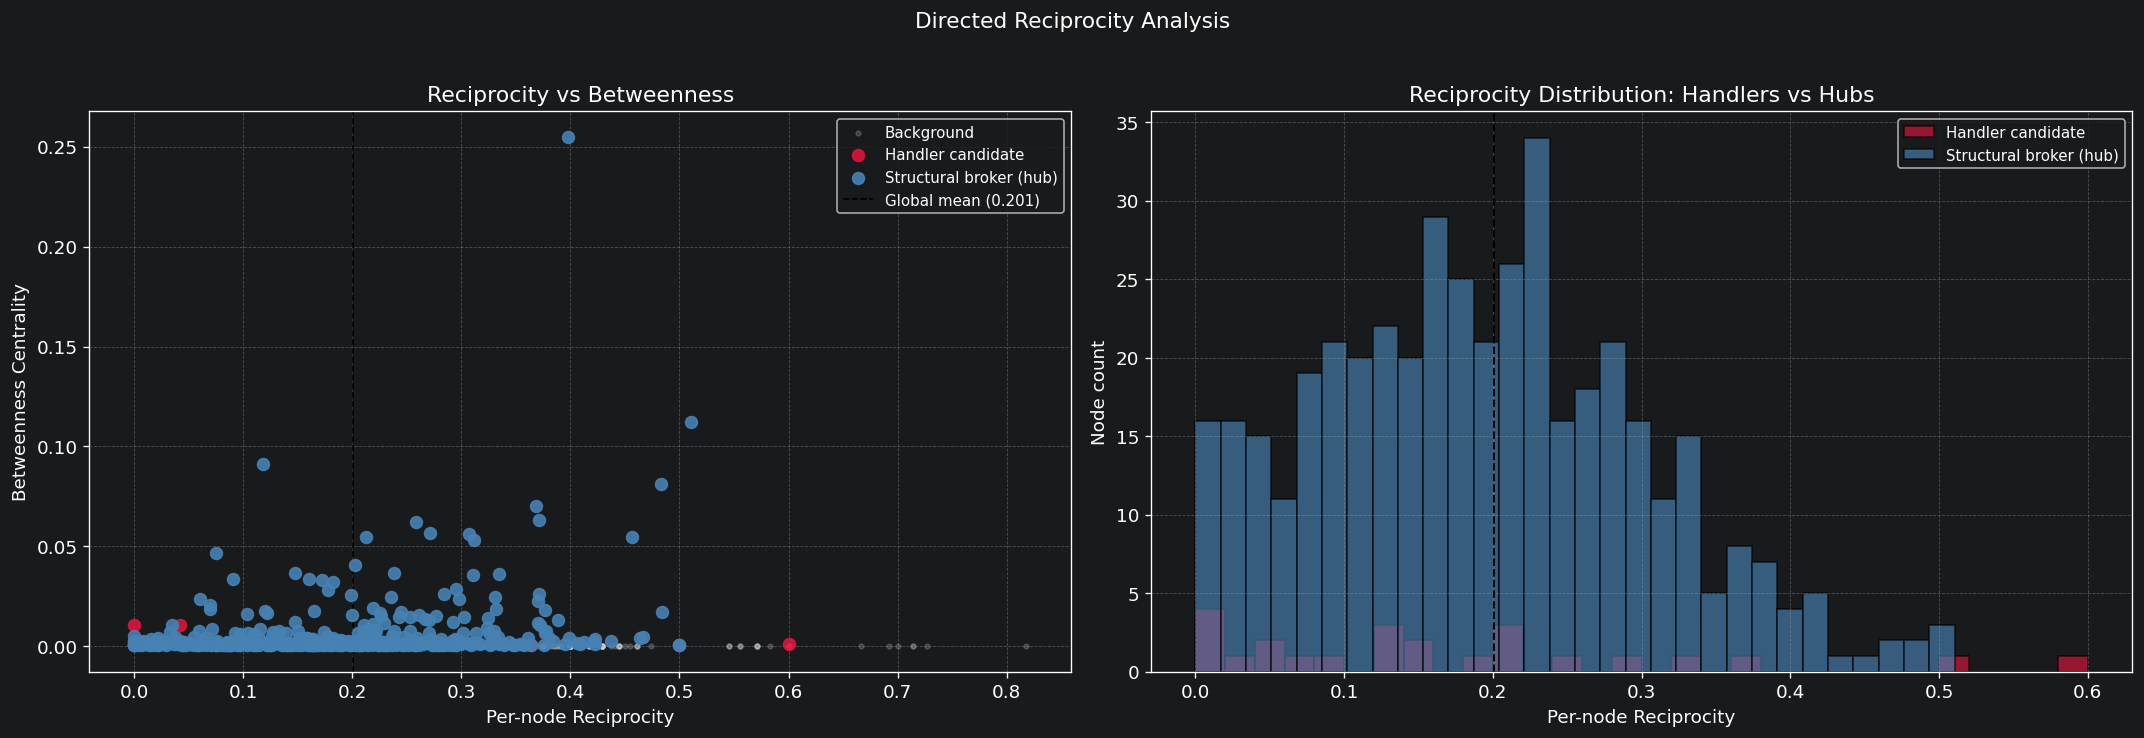


Handler candidates with low reciprocity (<= 0.000): 4
                     Email  Betweenness  Total_Degree  Reciprocity  Constraint  Comm_Span_Leiden
          ajones@uwtgc.org     0.010840             6          0.0    0.205827                 2
   barbara.sain@compaq.com     0.000962            16          0.0    0.148526                 2
valerie.ramsower@enron.com     0.000634            10          0.0    0.170201                 4
  afilas@keyspanenergy.com     0.000526            26          0.0    0.141972                 2


In [21]:
# ── Reciprocity by broker type ────────────────────────────────────────────────
colors_btype = {'Handler candidate': 'crimson',
                'Structural broker (hub)': 'steelblue',
                'Background': 'lightgrey'}

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for btype, grp in bridge_df.groupby('Broker_Type'):
    size  = 50 if btype != 'Background' else 8
    alpha = 0.9 if btype != 'Background' else 0.2
    axes[0].scatter(grp['Reciprocity'], grp['Betweenness'],
                    s=size, alpha=alpha, color=colors_btype[btype], label=btype,
                    zorder=3 if btype != 'Background' else 1)

axes[0].axvline(global_rec, color='black', linestyle='--', linewidth=1,
                label=f'Global mean ({global_rec:.3f})')
axes[0].set_xlabel('Per-node Reciprocity'); axes[0].set_ylabel('Betweenness Centrality')
axes[0].set_title('Reciprocity vs Betweenness'); axes[0].legend(fontsize=9)
axes[0].grid(True, linestyle='--', alpha=0.35)

for btype, grp in bridge_df[bridge_df['Broker_Type'] != 'Background'].groupby('Broker_Type'):
    axes[1].hist(grp['Reciprocity'].dropna(), bins=30, alpha=0.65,
                 color=colors_btype[btype], label=btype, edgecolor='black')
axes[1].axvline(global_rec, color='black', linestyle='--', linewidth=1.2)
axes[1].set_xlabel('Per-node Reciprocity'); axes[1].set_ylabel('Node count')
axes[1].set_title('Reciprocity Distribution: Handlers vs Hubs')
axes[1].legend(fontsize=9); axes[1].grid(True, linestyle='--', alpha=0.35)

plt.suptitle('Directed Reciprocity Analysis', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

rec_thresh = bridge_df['Reciprocity'].quantile(0.25)
low_rec_handlers = bridge_df[
    (bridge_df['Broker_Type'] == 'Handler candidate') &
    (bridge_df['Reciprocity'] <= rec_thresh)
].sort_values('Betweenness', ascending=False)
print(f'\nHandler candidates with low reciprocity (<= {rec_thresh:.3f}): {len(low_rec_handlers)}')
print(low_rec_handlers[['Email', 'Betweenness', 'Total_Degree',
                          'Reciprocity', 'Constraint', 'Comm_Span_Leiden']].to_string(index=False))

---
## Phase 5 — Statistical Anomaly Detection

Two complementary methods flag structurally unusual nodes:

| Method | Detects |
|---|---|
| **Isolation Forest** | Global multivariate outliers — nodes unlike the bulk population |
| **Local Outlier Factor** | Local density anomalies — nodes anomalous relative to their neighbourhood |

In [22]:
# ── Feature matrix (shared by both methods) ──────────────────────────────────
feature_cols = [
    'Betweenness', 'Total_Degree', 'handler_score',
    'Constraint', 'Comm_Span_Leiden', 'In_Degree', 'Out_Degree', 'Clustering'
]
X_scaled = StandardScaler().fit_transform(bridge_df[feature_cols].fillna(0))

# ── Isolation Forest ──────────────────────────────────────────────────────────
iso_forest = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
iso_forest.fit(X_scaled)
bridge_df['iso_score']   = iso_forest.decision_function(X_scaled)
bridge_df['iso_anomaly'] = iso_forest.predict(X_scaled)   # -1 = anomaly

# ── Local Outlier Factor ──────────────────────────────────────────────────────
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
bridge_df['lof_anomaly'] = lof.fit_predict(X_scaled)
bridge_df['lof_score']   = -lof.negative_outlier_factor_  # higher = more anomalous

n_iso = (bridge_df['iso_anomaly'] == -1).sum()
n_lof = (bridge_df['lof_anomaly'] == -1).sum()
print(f'Isolation Forest anomalies : {n_iso}')
print(f'LOF anomalies              : {n_lof}')

Isolation Forest anomalies : 454
LOF anomalies              : 454


C:\Users\beark\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


Flagged by BOTH methods: 59
IF only: 395  |  LOF only: 395


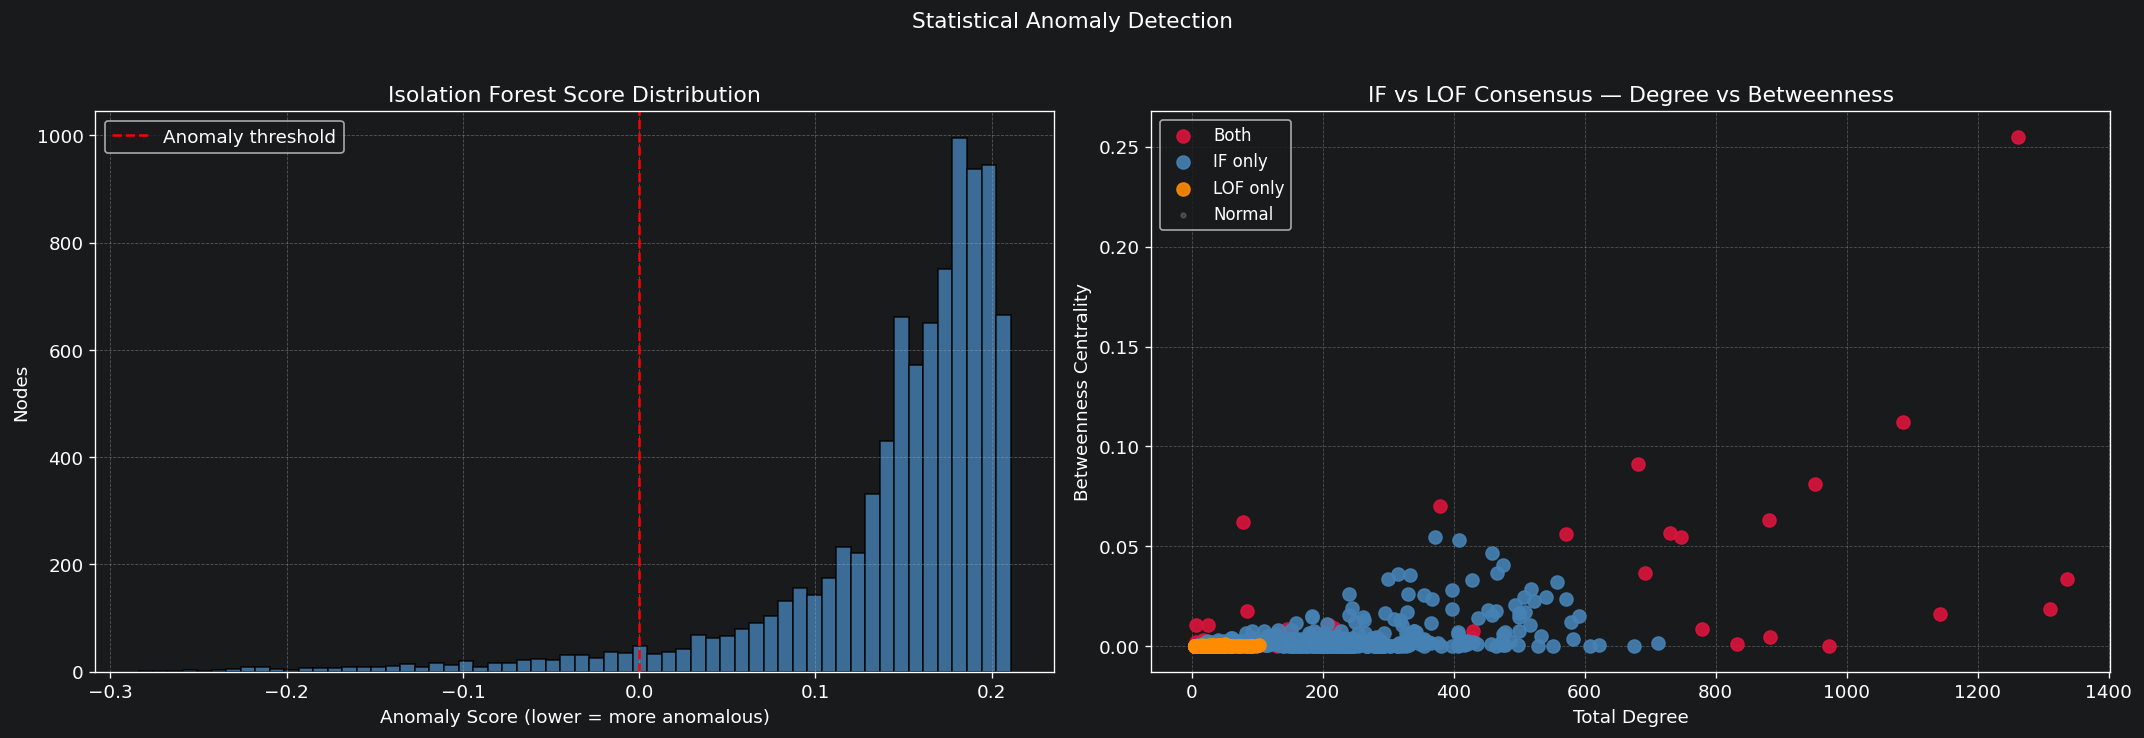


Nodes flagged by BOTH Isolation Forest and LOF:
                           Email  Betweenness  Total_Degree  Constraint  Comm_Span_Leiden  iso_score  lof_score             Broker_Type
         jeff.dasovich@enron.com     0.255010          1261    0.021038                12  -0.283813   6.250551 Structural broker (hub)
            tana.jones@enron.com     0.112113          1086    0.030087                11  -0.272333   2.736793 Structural broker (hub)
       sara.shackleton@enron.com     0.081260           952    0.036862                12  -0.268024   2.202543 Structural broker (hub)
           mark.taylor@enron.com     0.063355           882    0.052815                12  -0.262785   2.039741 Structural broker (hub)
        louise.kitchen@enron.com     0.056581           731    0.020047                11  -0.258947   1.601647 Structural broker (hub)
           susan.scott@enron.com     0.091321           682    0.012750                10  -0.257580   2.009500 Structural broker (hub)

In [23]:
# ── IF vs LOF consensus ──────────────────────────────────────────────────────
iso_set  = set(bridge_df[bridge_df['iso_anomaly'] == -1]['Node_ID'])
lof_set  = set(bridge_df[bridge_df['lof_anomaly'] == -1]['Node_ID'])
both_set = iso_set & lof_set

bridge_df['anomaly_consensus'] = bridge_df['Node_ID'].apply(
    lambda n: 'Both' if n in both_set
    else ('IF only' if n in iso_set
    else ('LOF only' if n in lof_set else 'Normal'))
)

print(f'Flagged by BOTH methods: {len(both_set)}')
print(f'IF only: {len(iso_set - lof_set)}  |  LOF only: {len(lof_set - iso_set)}')

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
color_map = {'Both': 'crimson', 'IF only': 'steelblue', 'LOF only': 'darkorange', 'Normal': 'lightgrey'}

# Left: IF score distribution
axes[0].hist(bridge_df['iso_score'], bins=60, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(bridge_df[bridge_df['iso_anomaly'] == -1]['iso_score'].max(),
                color='red', linestyle='--', label='Anomaly threshold')
axes[0].set_title('Isolation Forest Score Distribution')
axes[0].set_xlabel('Anomaly Score (lower = more anomalous)'); axes[0].set_ylabel('Nodes')
axes[0].legend(); axes[0].grid(True, linestyle='--', alpha=0.4)

# Right: Consensus scatter
for label, grp in bridge_df.groupby('anomaly_consensus'):
    size  = 60 if label != 'Normal' else 8
    alpha = 0.9 if label != 'Normal' else 0.2
    axes[1].scatter(grp['Total_Degree'], grp['Betweenness'],
                    s=size, alpha=alpha, color=color_map[label], label=label,
                    zorder=3 if label != 'Normal' else 1)
axes[1].set_title('IF vs LOF Consensus — Degree vs Betweenness')
axes[1].set_xlabel('Total Degree'); axes[1].set_ylabel('Betweenness Centrality')
axes[1].legend(fontsize=10); axes[1].grid(True, linestyle='--', alpha=0.35)

plt.suptitle('Statistical Anomaly Detection', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

# ── Consensus anomalies table ─────────────────────────────────────────────────
print('\nNodes flagged by BOTH Isolation Forest and LOF:')
both_df = bridge_df[bridge_df['Node_ID'].isin(both_set)].sort_values('iso_score')
cols = ['Email', 'Betweenness', 'Total_Degree', 'Constraint',
        'Comm_Span_Leiden', 'iso_score', 'lof_score', 'Broker_Type']
print(both_df[cols].to_string(index=False))

In [24]:
from sklearn.svm import OneClassSVM

# 1. Implement OC-SVM
oc_svm = OneClassSVM(kernel='rbf', gamma='auto', nu=0.05)
# Use X_scaled which is already defined in your Phase 5
bridge_df['ocsvm_anomaly'] = oc_svm.fit_predict(X_scaled)

# 2. Correct Consensus Logic (Filtering for -1 in all three)
consensus_anomalies = bridge_df[
    (bridge_df['iso_anomaly'] == -1) &
    (bridge_df['lof_anomaly'] == -1) &
    (bridge_df['ocsvm_anomaly'] == -1)
]

print(f"OC-SVM identified: {(bridge_df['ocsvm_anomaly'] == -1).sum()} anomalies")
print(f"True Consensus (IF + LOF + OC-SVM): {len(consensus_anomalies)}")

# Optional: View the top consensus anomalies by their decision scores
# (Assuming higher scores = more anomalous)
if not consensus_anomalies.empty:
    print("\nTop 5 Consensus Anomalies:")
    print(consensus_anomalies[['Email', 'iso_score', 'lof_score']].head())

OC-SVM identified: 608 anomalies
True Consensus (IF + LOF + OC-SVM): 46

Top 5 Consensus Anomalies:
                         Email  iso_score  lof_score
224        glen.hass@enron.com  -0.085719   1.562983
427      mark.guzman@enron.com  -0.181056   2.665568
444    jeff.dasovich@enron.com  -0.283813   6.250551
466  elizabeth.sager@enron.com  -0.251053   1.621458
550    james.steffes@enron.com  -0.237016   1.735732


---
## Phase 6 — Validation & Synthesis

### 6a. Modularity Null Test

Generate 100 configuration-model random graphs (preserving the degree sequence) and measure
Louvain modularity on each. If the observed modularity far exceeds the null distribution, the
community structure — and the covert-like clusters within it — are statistically significant.

In [25]:
N_ITER = 100
null_mods = []

print(f'Running {N_ITER} configuration-model randomisations...')
for i in range(N_ITER):
    deg_seq = [d for _, d in G_undir.degree()]
    G_rand  = nx.Graph(nx.configuration_model(deg_seq, seed=i))
    G_rand.remove_edges_from(nx.selfloop_edges(G_rand))
    if G_rand.number_of_edges() == 0:
        continue
    part_rand = community_louvain.best_partition(G_rand, random_state=i)
    null_mods.append(community_louvain.modularity(part_rand, G_rand))
    if (i + 1) % 25 == 0:
        print(f'  {i+1}/{N_ITER}  |  running null mean = {np.mean(null_mods):.4f}')

null_mods = np.array(null_mods)
p_value   = np.mean(null_mods >= mod_louvain)
z_score   = (mod_louvain - null_mods.mean()) / null_mods.std()

print(f'\nObserved Louvain modularity : {mod_louvain:.4f}')
print(f'Null mean modularity        : {null_mods.mean():.4f}  ± {null_mods.std():.4f}')
print(f'Z-score                     : {z_score:.2f}')
print(f'p-value (one-tailed)        : {p_value:.4f}')
if p_value < 0.05:
    print('→ Community structure is statistically significant (p < 0.05)')
else:
    print('→ Community structure is NOT significantly different from random at p < 0.05')

Running 100 configuration-model randomisations...
  25/100  |  running null mean = 0.1366
  50/100  |  running null mean = 0.1365
  75/100  |  running null mean = 0.1365
  100/100  |  running null mean = 0.1365

Observed Louvain modularity : 0.6394
Null mean modularity        : 0.1365  ± 0.0013
Z-score                     : 382.16
p-value (one-tailed)        : 0.0000
→ Community structure is statistically significant (p < 0.05)


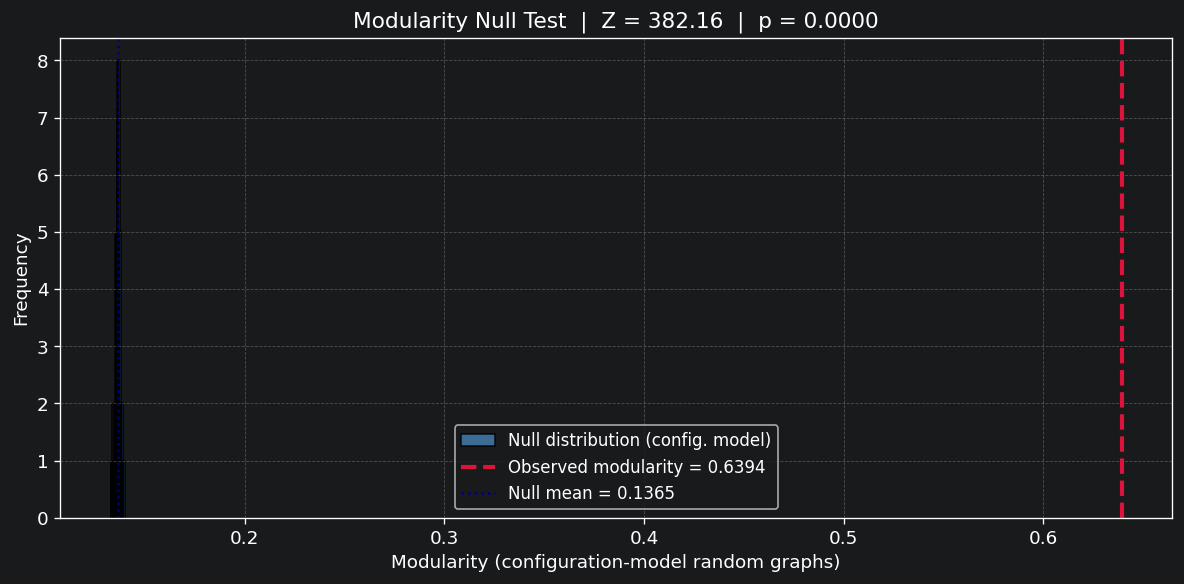

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(null_mods, bins=30, color='steelblue', edgecolor='black', alpha=0.8,
        label='Null distribution (config. model)')
ax.axvline(mod_louvain, color='crimson', linewidth=2.5, linestyle='--',
           label=f'Observed modularity = {mod_louvain:.4f}')
ax.axvline(null_mods.mean(), color='navy', linewidth=1.5, linestyle=':',
           label=f'Null mean = {null_mods.mean():.4f}')
extreme = null_mods[null_mods >= mod_louvain]
if len(extreme):
    ax.hist(extreme, bins=30, color='red', alpha=0.5, label=f'p-value region (p={p_value:.4f})')
ax.set_title(f'Modularity Null Test  |  Z = {z_score:.2f}  |  p = {p_value:.4f}', fontsize=13)
ax.set_xlabel('Modularity (configuration-model random graphs)')
ax.set_ylabel('Frequency')
ax.legend(fontsize=10); ax.grid(True, linestyle='--', alpha=0.35)
plt.tight_layout(); plt.show()

### 6b. Composite Multi-Method Suspicion Score

Normalise all detection signals to [0, 1] and sum them into a single composite score.

| Signal | Direction | Rationale |
|---|---|---|
| Isolation Forest score | inverted (more negative → higher) | Global multivariate anomaly |
| LOF score | as-is (higher = more anomalous) | Local density anomaly |
| Handler score | as-is | Disproportionate path control |
| Burt constraint | inverted (lower → higher) | Structural hole occupancy |
| Reciprocity | inverted (lower → higher) | Asymmetric communication |
| Community span | as-is | Inter-community brokerage |

In [27]:
def safe_norm(series):
    arr = series.fillna(0).values.reshape(-1, 1)
    return MinMaxScaler().fit_transform(arr).flatten()

bridge_df['sig_iso']         = safe_norm(-bridge_df['iso_score'])
bridge_df['sig_lof']         = safe_norm(bridge_df['lof_score'])
bridge_df['sig_handler']     = safe_norm(bridge_df['handler_score'])
bridge_df['sig_constraint']  = safe_norm(-bridge_df['Constraint'])
bridge_df['sig_reciprocity'] = safe_norm(-bridge_df['Reciprocity'])
bridge_df['sig_span']        = safe_norm(bridge_df['Comm_Span_Leiden'])


sig_cols = ['sig_iso', 'sig_lof', 'sig_handler', 'sig_constraint',
            'sig_reciprocity', 'sig_span']
bridge_df['suspicion_score'] = bridge_df[sig_cols].sum(axis=1)

top_suspects_all = (bridge_df
    .sort_values('suspicion_score', ascending=False)
    .head(30).reset_index(drop=True))
top_suspects_all.index += 1

print('Top 30 Nodes by Multi-Method Suspicion Score')
print('=' * 90)
display_cols = ['Email', 'suspicion_score', 'Betweenness', 'Total_Degree',
                'Constraint', 'Reciprocity', 'Comm_Span_Leiden',
                'iso_score', 'lof_score', 'Broker_Type']
print(top_suspects_all[display_cols].to_string())

Top 30 Nodes by Multi-Method Suspicion Score
                           Email  suspicion_score   Betweenness  Total_Degree  Constraint  Reciprocity  Comm_Span_Leiden  iso_score  lof_score              Broker_Type
1          kenneth.lay@enron.com         3.832718  1.866034e-02          1310    0.006167     0.069388                14  -0.240324   2.483511  Structural broker (hub)
2          kay.chapman@enron.com         3.637582  2.085851e-02           494    0.014970     0.069264                12  -0.215355   1.242034  Structural broker (hub)
3               ajones@uwtgc.org         3.582750  1.083998e-02             6    0.205827     0.000000                 2  -0.141911  14.428706        Handler candidate
4          susan.scott@enron.com         3.570906  9.132106e-02           682    0.012750     0.118033                10  -0.257580   2.009500  Structural broker (hub)
5        billy.lemmons@enron.com         3.561455  1.785788e-03           712    0.006086     0.036390             

In [42]:
# ── Ground-truth validation ───────────────────────────────────────────────────
known_bad_actors = {
    'jeff.skilling@enron.com':  'CEO — convicted fraud, conspiracy',
    'kenneth.lay@enron.com':    'Chairman/CEO — convicted fraud, conspiracy',
    'tim.belden@enron.com':     'Head of W. Trading — guilty plea, wire fraud',
    'ben.glisan@enron.com':     'Treasurer — guilty plea, conspiracy',
    'jeff.dasovich@enron.com':  'Govt Affairs — lobbied FERC during CA manipulation',
}

top_suspects_all['Known_Role'] = top_suspects_all['Email'].map(known_bad_actors).fillna('')
validated = top_suspects_all[top_suspects_all['Known_Role'] != '']

print(f'Known convicted/implicated individuals in top 30: {len(validated)}')
for _, row in validated.iterrows():
    print(f'  Rank {row.name}  {str(row["Email"]).ljust(40)} {row["Known_Role"]}')

Known convicted/implicated individuals in top 30: 3
  Rank 1  kenneth.lay@enron.com                    Chairman/CEO — convicted fraud, conspiracy
  Rank 9  jeff.skilling@enron.com                  CEO — convicted fraud, conspiracy
  Rank 12  jeff.dasovich@enron.com                  Govt Affairs — lobbied FERC during CA manipulation


### 6c. Network Map — Broker vs Handler Classification

Single-panel map showing handler candidates (red), structural brokers (blue), and background nodes.

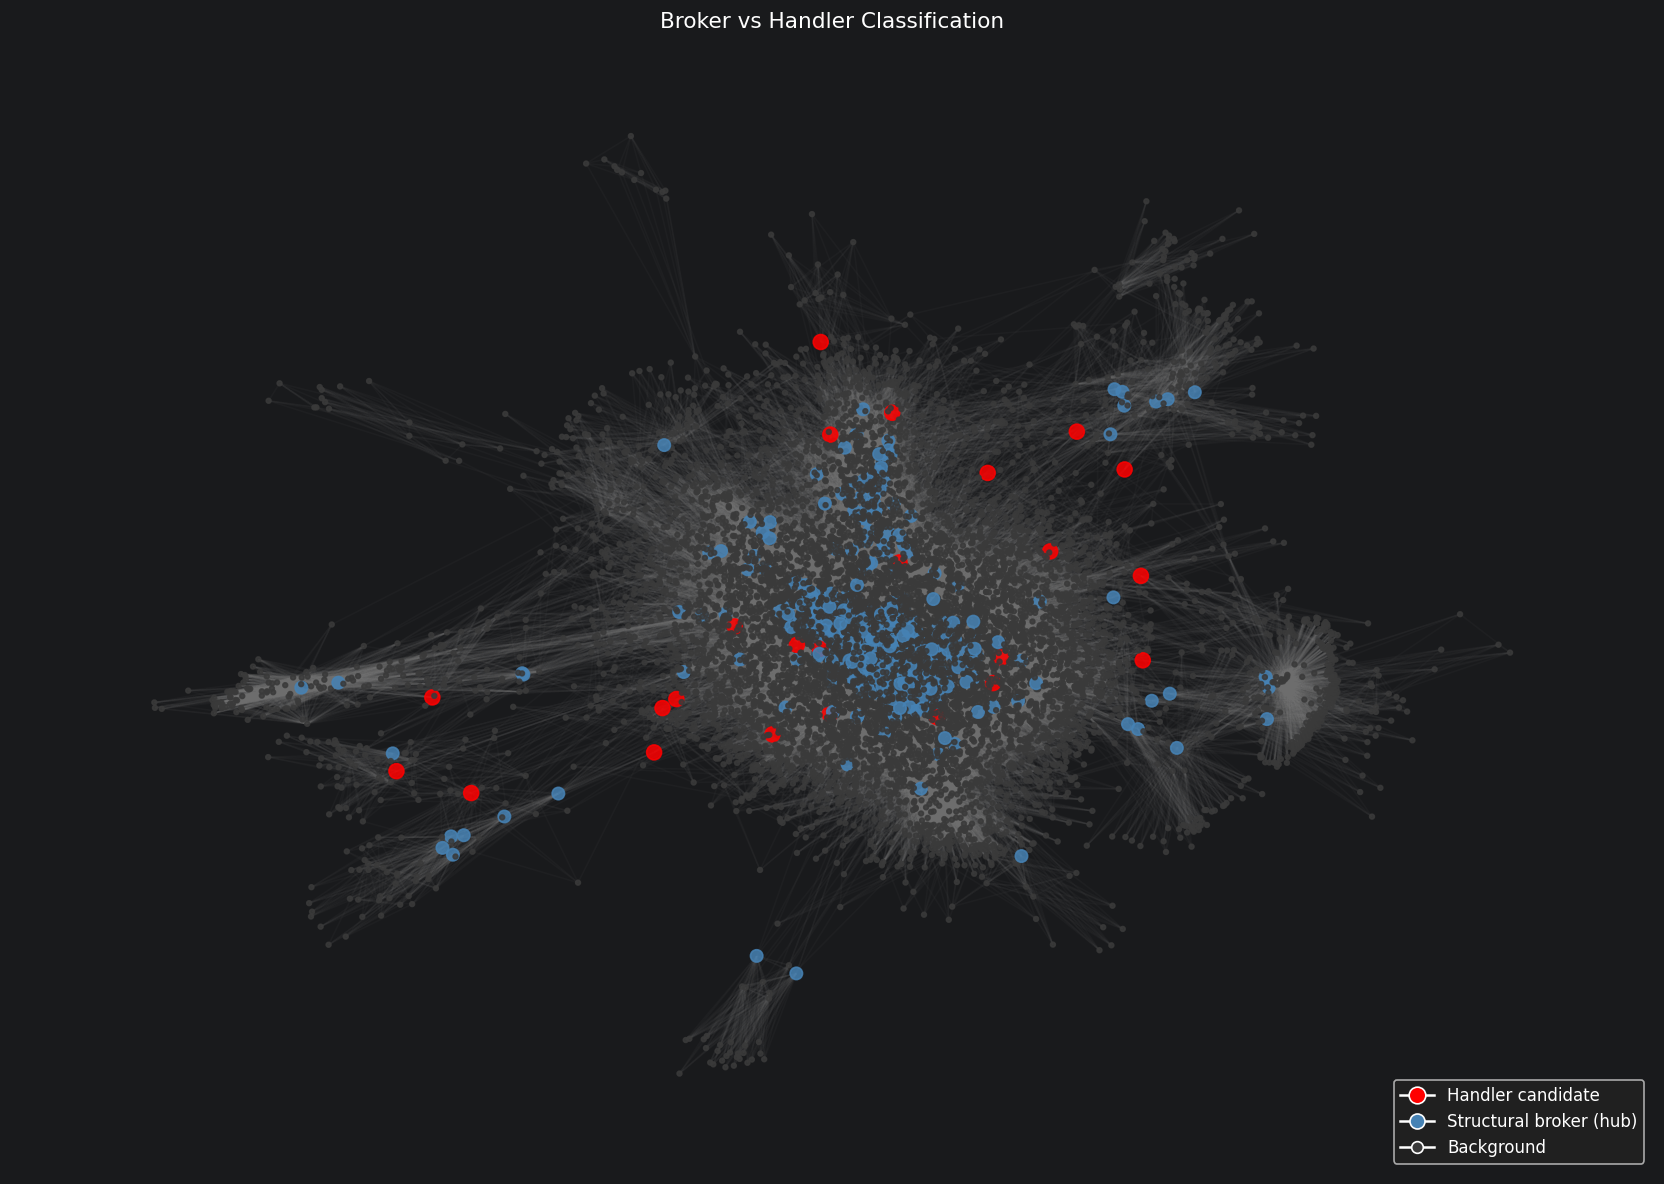

In [29]:
broker_lookup = bridge_df.set_index('Node_ID')['Broker_Type']

node_colors_map = [
    'red' if broker_lookup.get(n) == 'Handler candidate'
    else 'steelblue' if broker_lookup.get(n) == 'Structural broker (hub)'
    else '#3a3a3a'
    for n in G_dir.nodes()
]
node_sizes_map = [
    80  if broker_lookup.get(n) == 'Handler candidate'
    else 55 if broker_lookup.get(n) == 'Structural broker (hub)'
    else 8
    for n in G_dir.nodes()
]

fig, ax = plt.subplots(figsize=(14, 10))
nx.draw_networkx_edges(G_dir, pos, ax=ax, alpha=0.05, edge_color='gray', arrows=False)
nx.draw_networkx_nodes(G_dir, pos, ax=ax,
                       node_color=node_colors_map,
                       node_size=node_sizes_map, alpha=0.85)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
           markersize=10, label='Handler candidate'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue',
           markersize=9, label='Structural broker (hub)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3a3a3a',
           markersize=7, label='Background'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10,
          facecolor='#222', labelcolor='white')
ax.set_title(f'Broker vs Handler Classification', fontsize=13)
ax.axis('off')
plt.tight_layout(); plt.show()

In [37]:
# Replace 10 with the Community ID you want to investigate
target_community = 17

# 1. Filter the bridge dataframe for nodes in that community
comm_nodes = bridge_df[bridge_df['Community_Leiden'] == target_community].copy()

# 2. Identify the 'Bridges' (Nodes that talk to other communities)
# We look for nodes with high 'Brokerage_Span' or specific 'Broker_Type'
bridges = comm_nodes[
    (comm_nodes['Broker_Type'] == 'Handler candidate') |
    (comm_nodes['Broker_Type'] == 'Structural broker (hub)')
].sort_values(by='suspicion_score', ascending=False)

# 3. Filter for internal Enron addresses only
internal_bridges = bridges[bridges['Email'].str.contains('@enron.com', na=False)]

print(f"Internal Enron Bridges for Community {target_community}:")
print(internal_bridges[['Email', 'Broker_Type', 'suspicion_score', 'Betweenness']])

Internal Enron Bridges for Community 17:
                           Email              Broker_Type  suspicion_score  \
1795       mark.fisher@enron.com  Structural broker (hub)         2.626066   
5297       ilan.caplan@enron.com        Handler candidate         2.617082   
4076       jeff.maurer@enron.com  Structural broker (hub)         2.344487   
4069  hollis.kimbrough@enron.com  Structural broker (hub)         1.977146   
4081         jeff.duff@enron.com  Structural broker (hub)         1.957081   
4073     kurt.anderson@enron.com  Structural broker (hub)         1.619024   
1760       mark.walker@enron.com  Structural broker (hub)         1.580080   

      Betweenness  
1795     0.003908  
5297     0.003068  
4076     0.001110  
4069     0.004155  
4081     0.001892  
4073     0.000612  
1760     0.000440  


In [39]:
target_comm = 10

# 1. Identify the Node_IDs (integers) belonging to Community 10
# Note: Ensure you use 'Community_Louvain' or 'Community_Leiden' as per your notebook
comm_10_node_ids = set(bridge_df[bridge_df['Community_Louvain'] == target_comm]['Node_ID'])

# 2. Find nodes OUTSIDE Community 10 that have edges with nodes INSIDE Community 10
from collections import Counter
bridge_candidates = []

for u, v in G_dir.edges():
    # Case A: Enron person (u) sends to the external group (v)
    if u not in comm_10_node_ids and v in comm_10_node_ids:
        bridge_candidates.append(u)
    # Case B: External group (u) sends to Enron person (v)
    elif u in comm_10_node_ids and v not in comm_10_node_ids:
        bridge_candidates.append(v)

# 3. Count how many distinct people in Comm 10 each "outsider" talks to
bridge_counts = Counter(bridge_candidates)

# 4. Filter bridge_df for these IDs, keep only @enron.com, and add the counts
results = bridge_df[bridge_df['Node_ID'].isin(bridge_counts.keys())].copy()
results = results[results['Email'].str.contains('@enron.com', na=False)]
results['Connections_to_Comm10'] = results['Node_ID'].map(bridge_counts)

# 5. Display the true Gatekeepers
print(f"Enron Employees (Gatekeepers) managing Community {target_comm}:")
display_cols = ['Email', 'Connections_to_Comm10', 'suspicion_score', 'Broker_Type']
print(results[display_cols].sort_values(by='Connections_to_Comm10', ascending=False).head(10))

Enron Employees (Gatekeepers) managing Community 10:
                        Email  Connections_to_Comm10  suspicion_score  \
444   jeff.dasovich@enron.com                    175         3.471307   
446      susan.mara@enron.com                     80         3.035821   
3562       jdasovic@enron.com                     77         2.752700   
1829   robert.frank@enron.com                     59         2.835007   
3563          smara@enron.com                     44         2.260244   
1359       m..scott@enron.com                     38         2.795180   
2249  lisa.gillette@enron.com                     23         2.416169   
440   david.parquet@enron.com                     16         2.738331   
549    joseph.alamo@enron.com                     13         2.762260   
1761    alan.comnes@enron.com                     10         3.394354   

                  Broker_Type  
444   Structural broker (hub)  
446   Structural broker (hub)  
3562               Background  
1829           

In [41]:
target_comm = 16

# 1. Identify the Node_IDs (integers) belonging to Community 10
# Note: Ensure you use 'Community_Louvain' or 'Community_Leiden' as per your notebook
comm_10_node_ids = set(bridge_df[bridge_df['Community_Louvain'] == target_comm]['Node_ID'])

# 2. Find nodes OUTSIDE Community 10 that have edges with nodes INSIDE Community 10
from collections import Counter
bridge_candidates = []

for u, v in G_dir.edges():
    # Case A: Enron person (u) sends to the external group (v)
    if u not in comm_10_node_ids and v in comm_10_node_ids:
        bridge_candidates.append(u)
    # Case B: External group (u) sends to Enron person (v)
    elif u in comm_10_node_ids and v not in comm_10_node_ids:
        bridge_candidates.append(v)

# 3. Count how many distinct people in Comm 10 each "outsider" talks to
bridge_counts = Counter(bridge_candidates)

# 4. Filter bridge_df for these IDs, keep only @enron.com, and add the counts
results = bridge_df[bridge_df['Node_ID'].isin(bridge_counts.keys())].copy()
results = results[results['Email'].str.contains('@enron.com', na=False)]
results['Connections_to_Comm10'] = results['Node_ID'].map(bridge_counts)

# 5. Display the true Gatekeepers
print(f"Enron Employees (Gatekeepers) managing Community {target_comm}:")
display_cols = ['Email', 'Connections_to_Comm10', 'suspicion_score', 'Broker_Type']
print(results[display_cols].sort_values(by='Connections_to_Comm10', ascending=False).head(10))

Enron Employees (Gatekeepers) managing Community 16:
                            Email  Connections_to_Comm10  suspicion_score  \
435           mary.hain@enron.com                     41         3.425735   
3607        tom.delaney@enron.com                     34         3.023982   
771           lysa.akin@enron.com                     18         3.294597   
1761        alan.comnes@enron.com                      6         3.394354   
445        paul.kaufman@enron.com                      4         3.266175   
4074              mhain@enron.com                      4         1.932716   
2506  robert.eickenroht@enron.com                      3         3.115395   
3050       steve.walton@enron.com                      3         2.538608   
2860          andrew.wu@enron.com                      3         3.213511   
426       sean.crandall@enron.com                      3         2.979904   

                  Broker_Type  
435   Structural broker (hub)  
3607               Background  
771

---
## Summary & Interpretation Space

Use the cells below to write your analysis and interpretation of the results.

**Key questions to address:**

1. **Community structure**: Are the detected communities statistically significant (null test)? What do the covert-candidate communities look like — are they genuinely insular or just small/specialised teams?

2. **Handler vs broker distinction**: Do the handler candidates (high betweenness, low degree) plausibly suggest covert coordination, or do their email addresses indicate normal organisational roles (e.g., executive assistants, IT admins)?

3. **Anomaly detection convergence**: Where Isolation Forest, LOF, and the structural metrics agree, is the signal stronger? What does the composite suspicion score reveal that individual methods miss?

4. **Ground-truth check**: How many known convicted individuals appear in the top-30 suspect list? Does their presence validate the pipeline, and what does their *absence* (if any) suggest about limitations?

5. **Alternative explanations**: Could the flagged patterns be explained by normal organisational hierarchy, departmental boundaries, email forwarding behaviour, or dataset incompleteness (only 150 mailboxes in the Enron corpus)?

In [30]:
# ── Quick reference: summary statistics ───────────────────────────────────────
print('PIPELINE SUMMARY')
print('=' * 60)
print(f'Graph: {G_dir.number_of_nodes()} nodes, {G_dir.number_of_edges()} edges (k-core k={CHOSEN_K})')
print(f'Communities: Louvain={n_comm_louvain}, Leiden={n_comm_leiden}')
print(f'Modularity:  Louvain={mod_louvain:.4f}, Leiden={part_leiden.modularity:.4f}')
print(f'Null test:   z={z_score:.2f}, p={p_value:.4f}')
print(f'Covert-candidate communities: Louvain={len(covert_louvain)}, Leiden={len(covert_leiden)}')
print(f'Handler candidates: {(bridge_df["Broker_Type"]=="Handler candidate").sum()}')
print(f'Structural brokers: {(bridge_df["Broker_Type"]=="Structural broker (hub)").sum()}')
print(f'IF anomalies: {n_iso}  |  LOF anomalies: {n_lof}  |  Both: {len(both_set)}')
print(f'Known bad actors in top 30: {len(validated)}')

PIPELINE SUMMARY
Graph: 9066 nodes, 160005 edges (k-core k=5)
Communities: Louvain=19, Leiden=20
Modularity:  Louvain=0.6394, Leiden=0.5344
Null test:   z=382.16, p=0.0000
Covert-candidate communities: Louvain=3, Leiden=3
Handler candidates: 24
Structural brokers: 430
IF anomalies: 454  |  LOF anomalies: 454  |  Both: 59
Known bad actors in top 30: 3
